# Trajectory Analysis: Interactive Exploration

This notebook visualizes GPP and SVH time series along with historical satellite imagery for specific pixels.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import leafmap.maplibregl as leafmap

import os
os.environ['PYTHONUTF8'] = '1'

## 1. Load Data

Specify which pixel to explore:

In [2]:
# ── Selection mode ────────────────────────────────────────────────────────────
# Option A: pick a random pixel from a specific cluster (-1 = noise, 0, 1, 2)
cluster_to_explore = 0

# Option B: pin an exact pixel (set to an integer to override Option A)
pixel_id_override = None   # e.g. pixel_id_override = 123456

# ── Paths ─────────────────────────────────────────────────────────────────────
results_file = "../data/trajectory_results.parquet"   # slim 5-col output
raw_file     = "../data/abandoned_ag_gpp_2000_2022_SA.parquet"

In [3]:
import random
con = duckdb.connect()

if pixel_id_override is not None:
    query = f"""
        SELECT pixel_id, latitude, longitude, cluster, cluster_prob
        FROM read_parquet('{results_file}')
        WHERE pixel_id = {pixel_id_override}
        LIMIT 1
    """
else:
    seed = random.randint(1, 9999)
    query = f"""
        SELECT pixel_id, latitude, longitude, cluster, cluster_prob
        FROM (
            SELECT pixel_id, latitude, longitude, cluster, cluster_prob
            FROM read_parquet('{results_file}')
            WHERE cluster = {cluster_to_explore}
        ) t
        USING SAMPLE reservoir(1 ROWS) REPEATABLE ({seed})
    """

result = con.execute(query).fetchdf()
if result.empty:
    raise ValueError(f"No pixels found for cluster={cluster_to_explore}. Check the results file.")

meta     = result.iloc[0]
pixel_id = int(meta['pixel_id'])
lat      = float(meta['latitude'])
lon      = float(meta['longitude'])

print("=" * 50)
print(f"Pixel ID:     {pixel_id}")
print(f"Lat / Lon:    {lat:.5f}, {lon:.5f}")
print(f"Cluster:      {int(meta['cluster'])}  (prob: {meta['cluster_prob']:.3f})")
print("=" * 50)

Pixel ID:     8874
Lat / Lon:    -33.19567, 18.27295
Cluster:      0  (prob: 1.000)


In [4]:
# pixel_id is not globally unique in the raw data — use lat/lon to pinpoint the row
tol = 0.001  # ~100 m tolerance for float32 coordinate match
query = f"""
    SELECT *
    FROM read_parquet('{raw_file}')
    WHERE pixel_id = {pixel_id}
      AND latitude  BETWEEN {lat - tol} AND {lat + tol}
      AND longitude BETWEEN {lon - tol} AND {lon + tol}
    LIMIT 1
"""
raw = con.execute(query).fetchdf()
con.close()

if raw.empty:
    print("WARNING: pixel not found in raw data — try a different pixel_id_override")
else:
    print(f"Loaded pixel {pixel_id}  |  sanlc_2022 class: {raw['sanlc_2022'].iloc[0]}")
raw.head(1)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded pixel 8874  |  sanlc_2022 class: 2


,geo,BII All,BII All Plants,BII All Vertebrates,BII Amphibians,BII Birds,BII Forbs,BII Graminoids,BII Mammals,BII Reptiles,...,SVH_2018,SVH_2019,SVH_2020,SVH_2021,SVH_2022,eco_id,latitude,longitude,pixel_id,sanlc_2022
0,"{'type': 'Point', 'coordinates': [18.272945604...",0.434985,0.409599,0.548656,0.493726,0.591857,0.458606,0.525204,0.463338,0.51997,...,21,22,23,22,21,89,-33.195669,18.272946,8874,2


## 2. Plot Time Series

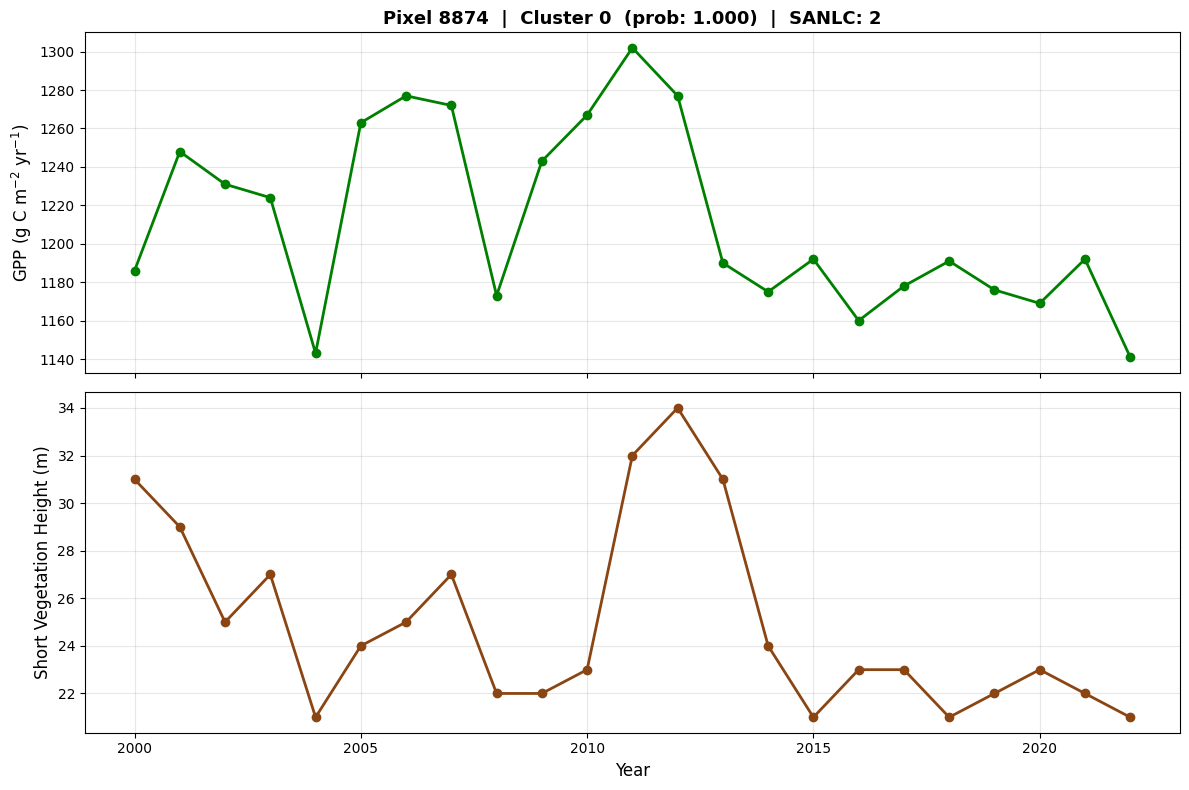

In [5]:
gpp_cols = sorted([c for c in raw.columns if c.startswith('GPP_')], key=lambda x: int(x.split('_')[1]))
svh_cols = sorted([c for c in raw.columns if c.startswith('SVH_')], key=lambda x: int(x.split('_')[1]))

gpp_data = raw[gpp_cols].iloc[0].values.astype(float)
svh_data = raw[svh_cols].iloc[0].values.astype(float)
years    = [int(c.split('_')[1]) for c in gpp_cols]

cluster_id   = int(meta['cluster'])
cluster_prob = float(meta['cluster_prob'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(years, gpp_data, 'o-', color='green', linewidth=2, markersize=6)
ax1.set_ylabel('GPP (g C m$^{-2}$ yr$^{-1}$)', fontsize=12)
ax1.set_title(
    f'Pixel {pixel_id}  |  Cluster {cluster_id}  (prob: {cluster_prob:.3f})  '
    f'|  SANLC: {raw["sanlc_2022"].iloc[0]}',
    fontsize=13, fontweight='bold'
)
ax1.grid(True, alpha=0.3)

ax2.plot(years, svh_data, 'o-', color='saddlebrown', linewidth=2, markersize=6)
ax2.set_ylabel('Short Vegetation Height (m)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Interactive Map with Historical Imagery

The map includes:
- **Layer control** (left sidebar) to switch between imagery dates
- Current Google Satellite imagery
- Historical Esri Wayback imagery for selected years

In [6]:
m = leafmap.Map(center=[lon, lat], zoom=15, sidebar_visible=True)
m.add_basemap("SATELLITE")
m.add_wayback_layer(date="2000-01-01")
m.add_wayback_layer(date="2025-01-01")
m.add_marker(lng_lat=[lon, lat], options={"color": "red"})
m

2000-01-01 is not available. Using the closest date: 2014-02-20
2025-01-01 is not available. Using the closest date: 2024-12-12


Html(children=[<leafmap.maplibregl.Map object at 0x000002708D817230>, Card(children=[Row(children=[Btn(childre…

In [18]:
m = leafmap.Map(center=[lon, lat], zoom=15, sidebar_visible=True, layer_manager_expanded=False)
m.add_wayback_time_slider(default_index=-1)
m.add_marker(lng_lat=[lon, lat], options={"color": "red"})
m

Html(children=[<leafmap.maplibregl.Map object at 0x0000024907C01450>, Card(children=[Row(children=[Btn(childre…

## Instructions

1. **View different time periods**: Use the layer control in the left sidebar to toggle between imagery dates
2. **Zoom and pan**: Use mouse/trackpad to explore the area
3. **Compare with plots**: Look for land cover changes that align with GPP/SVH trends

To explore a different pixel:
- Change `pixel_index`, `pixel_id`, or `cluster` in the "Load Data" section
- Re-run all cells

To add more Wayback years:
- Modify the `wayback_years` list (e.g., `[2005, 2010, 2015, 2020]`)
- Re-run the map cells

## 4. Image Chip Time Series

Monthly or aggregated composite chips for the selected pixel, spanning 2000–present.

| Period | Data source | Resolution |
|---|---|---|
| 2000 – 2012 | Landsat 5 + 7 C2 L2 (surface reflectance) | 30 m |
| 2013 – present | NASA HLS L30 + S30 (surface reflectance) | 30 m |

**Vis combos** (adapted from the Landsat Time Series Explorer JS source):
- `'RED/GREEN/BLUE'` — True Colour (TCI)
- `'SWIR1/NIR/GREEN'` — False Colour (FCI) — vegetation vigour / burn detection
- `'NIR/RED/GREEN'` — Standard near-IR false colour
- `'NIR/SWIR1/RED'` — Agriculture / moisture composite

**`period_months`** controls the aggregation window per chip:
- `1` → one chip per month (default)
- `4` with `months=[6]` → single Jun–Sep dry-season composite per year
- `12` with `months=[1]` → annual composite

In [7]:
# ── Chip configuration ────────────────────────────────────────────────────────
start_year    = 2000         # back to 2000 (Landsat 5/7 era); HLS starts 2013
end_year      = 2022
months        = [6] # start month of each column (= one chip per entry)
period_months = 4            # months per chip: 1=monthly, 4=seasonal, 12=annual
                             #   e.g. months=[6], period_months=4  → single Jun-Sep chip per year
chip_km       = 3            # chip width in km

# Vis combo — R/G/B band assignment for each chip thumbnail.
# Adapted from the Landsat Time Series Explorer RGB_PARAMS (JS source):
#   'RED/GREEN/BLUE'   → True Colour (TCI)
#   'SWIR1/NIR/GREEN'  → False Colour (FCI) — highlights vegetation vigour
#   'NIR/RED/GREEN'    → Standard near-IR false colour
#   'NIR/SWIR1/RED'    → Agriculture / moisture composite
vis_combo     = 'NIR/RED/GREEN'

# HLS sensor(s) — only applies for years >= 2013, <2013 uses landsat 5 and 7:
#   'L30' (Landsat-based HLS), 'S30' (Sentinel-2 HLS), or 'both'
hls_source    = 'both'

In [8]:
import ee
import requests
import calendar
import matplotlib.image as mpimg
import numpy as np
from io import BytesIO

# ── GEE initialisation ────────────────────────────────────────────────────────
try:
    ee.Initialize(project='ee-gsingh')
    print("GEE initialised (ee-gsingh)")
except Exception as e:
    print(f"GEE init error: {e}")

# ── Visualisation parameters ──────────────────────────────────────────────────
# Applied after scaling to reflectance (0–1) for both HLS and Landsat.
# Adapted from the Landsat Time Series Explorer JS RGB_PARAMS.
RGB_PARAMS = {
    'SWIR1/NIR/GREEN': dict(bands=['SWIR1','NIR','GREEN'], min=0.0, max=0.45, gamma=1.0),
    'RED/GREEN/BLUE':  dict(bands=['RED','GREEN','BLUE'],  min=0.01, max=0.18, gamma=1.2),
    'NIR/RED/GREEN':   dict(bands=['NIR','RED','GREEN'],   min=0.0, max=0.45, gamma=0.95),
    'NIR/SWIR1/RED':   dict(bands=['NIR','SWIR1','RED'],   min=0.0, max=0.45, gamma=1.0),
}

_SPECTRAL = ['RED', 'GREEN', 'BLUE', 'NIR', 'SWIR1', 'SWIR2']

# HLS band names in GEE (HLSS30 uses B4/B3/B2, NOT B04/B03/B02)
_HLS_IN = {
    'L30': ['B4', 'B3', 'B2', 'B5',  'B6',  'B7',  'Fmask'],
    'S30': ['B4', 'B3', 'B2', 'B8A', 'B11', 'B12', 'Fmask'],
}
_HLS_OUT = _SPECTRAL + ['Fmask']

# ── Date helpers ──────────────────────────────────────────────────────────────

def _period_end_dt(year, start_month, period_months):
    """Return the last calendar date of a period of `period_months` months."""
    last_month = start_month + period_months - 1
    end_year   = year + (last_month - 1) // 12
    end_month  = (last_month - 1) % 12 + 1
    return f'{end_year}-{end_month:02d}-{calendar.monthrange(end_year, end_month)[1]}'

def _period_label(start_month, period_months):
    """Human-readable column label, e.g. 'Jun' or 'Jun-Sep'."""
    abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    if period_months == 1:
        return abbr[start_month - 1]
    last_month = (start_month + period_months - 2) % 12 + 1
    return f'{abbr[start_month-1]}-{abbr[last_month-1]}'

# ── Cloud masking ─────────────────────────────────────────────────────────────

def _mask_hls_clouds(img):
    """Per-pixel HLS cloud mask via Fmask (bits 1/2/3)."""
    fmask = img.select('Fmask')
    bits  = (1 << 1) | (1 << 2) | (1 << 3)
    return img.updateMask(fmask.bitwiseAnd(bits).eq(0))

def _mask_landsat_clouds(img):
    """Landsat C2 L2 cloud + shadow mask via QA_PIXEL (bits 3/4)."""
    qa   = img.select('QA_PIXEL')
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    return img.updateMask(mask)

def _scale_rename_ls57(img):
    """Scale Landsat 5/7 C2 L2 SR bands to reflectance and rename to _SPECTRAL."""
    scaled = (img.select(['SR_B3','SR_B2','SR_B1','SR_B4','SR_B5','SR_B7'])
                 .multiply(0.0000275).add(-0.2)
                 .rename(_SPECTRAL))
    return scaled.addBands(img.select('QA_PIXEL'))

# ── Unified chip function ─────────────────────────────────────────────────────

def get_chip(lat, lon, year, month, period_months=1,
             vis_combo='SWIR1/NIR/GREEN', chip_km=3, hls_source='both'):
    """
    Fetch a median composite thumbnail centred on (lat, lon).

    Data source
    -----------
    year >= 2013 : NASA HLS (HLSL30 + HLSS30, 30 m, already in reflectance)
    year  < 2013 : Landsat 5 + 7 C2 L2 (30 m, scaled to reflectance)

    period_months
    -------------
    1  → single month (default)
    4  → 4-month seasonal composite (set months=[6] for Jun-Sep)
    12 → full-year composite (set months=[1])

    Returns a NumPy RGBA array for ax.imshow(), or None on failure.
    """
    point    = ee.Geometry.Point([lon, lat])
    region   = point.buffer(chip_km * 1000 / 2).bounds()
    start_dt = f'{year}-{month:02d}-01'
    end_dt   = _period_end_dt(year, month, period_months)

    if year >= 2013:
        # ── HLS ──────────────────────────────────────────────────────────────
        parts = []
        if hls_source in ('L30', 'both'):
            parts.append(ee.ImageCollection('NASA/HLS/HLSL30/v002')
                         .filterBounds(point).filterDate(start_dt, end_dt)
                         .filter(ee.Filter.lt('CLOUD_COVERAGE', 30))
                         .select(_HLS_IN['L30'], _HLS_OUT))
        if hls_source in ('S30', 'both'):
            parts.append(ee.ImageCollection('NASA/HLS/HLSS30/v002')
                         .filterBounds(point).filterDate(start_dt, end_dt)
                         .filter(ee.Filter.lt('CLOUD_COVERAGE', 30))
                         .select(_HLS_IN['S30'], _HLS_OUT))
        merged = parts[0].merge(parts[1]) if len(parts) == 2 else parts[0]
        masked = merged.map(_mask_hls_clouds).select(_SPECTRAL)

    else:
        # ── Landsat 5 + 7 C2 L2 ─────────────────────────────────────────────
        def _prep_ls(col_id):
            return (ee.ImageCollection(col_id)
                    .filterBounds(point).filterDate(start_dt, end_dt)
                    .filter(ee.Filter.lt('CLOUD_COVER', 30))
                    .map(_scale_rename_ls57)
                    .map(_mask_landsat_clouds)
                    .select(_SPECTRAL))
        merged = _prep_ls('LANDSAT/LT05/C02/T1_L2').merge(
                 _prep_ls('LANDSAT/LE07/C02/T1_L2'))
        masked = merged

    # ee.Algorithms.If guards against the empty-collection case:
    # when merged has 0 images, .median() returns a 0-band image and
    # .unmask(0) would fail with "Got 0 and 1 bands".
    blank = ee.Image.constant([0] * 6).rename(_SPECTRAL)
    img   = ee.Image(ee.Algorithms.If(
        merged.size().gt(0),
        masked.median().unmask(0),
        blank,
    ))

    vp      = RGB_PARAMS[vis_combo]
    vis_img = img.select(vp['bands']).visualize(min=vp['min'], max=vp['max'], gamma=vp['gamma'])

    try:
        url  = vis_img.getThumbURL(dict(dimensions=256, region=region, format='png'))
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        return mpimg.imread(BytesIO(resp.content), format='png')
    except Exception as exc:
        print(f"  Error {year}-{month:02d}: {exc}")
        return None

GEE initialised (ee-gsingh)


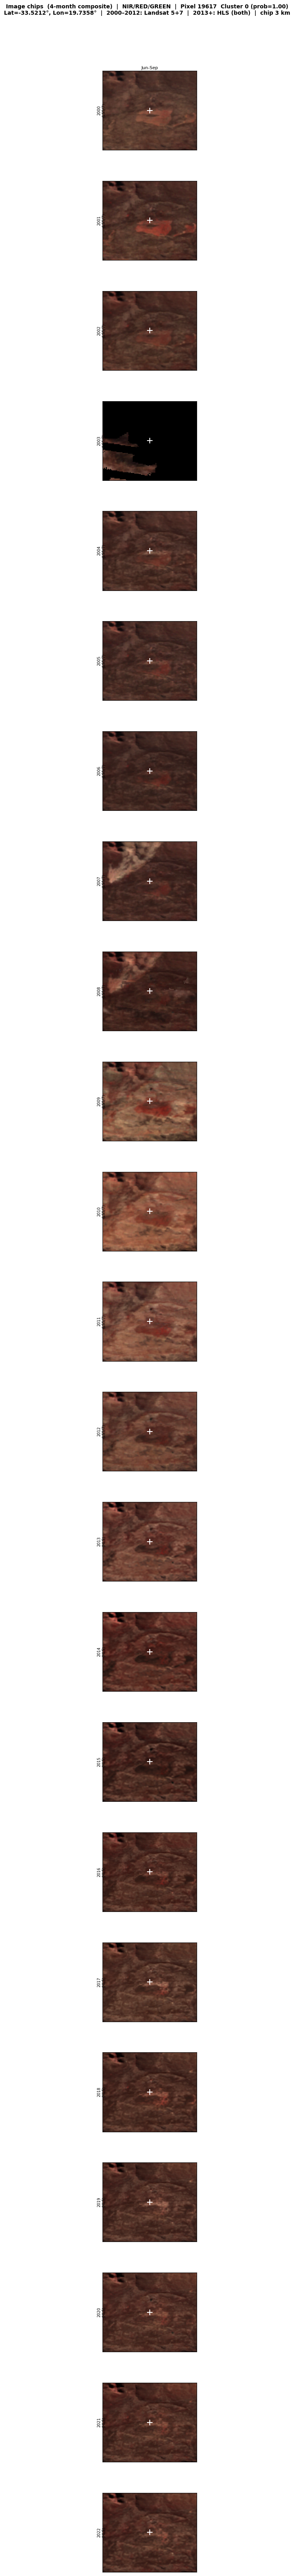

In [11]:
years_list = list(range(start_year, end_year + 1))
n_years    = len(years_list)
n_cols     = len(months)

fig, axes = plt.subplots(
    n_years, n_cols,
    figsize=(n_cols * 2.8, n_years * 2.8),
    squeeze=False,
)

period_desc = (f'{period_months}-month composite' if period_months > 1 else 'monthly')
fig.suptitle(
    f'Image chips  ({period_desc})  |  {vis_combo}  |  '
    f'Pixel {pixel_id}  Cluster {cluster_id} (prob={cluster_prob:.2f})\n'
    f'Lat={lat:.4f}\u00b0, Lon={lon:.4f}\u00b0  |  '
    f'2000\u20132012: Landsat 5+7  |  2013+: HLS ({hls_source})  |  chip {chip_km} km',
    fontsize=10, fontweight='bold', y=1.01,
)

# Column headers — period label (e.g. 'Jun' or 'Jun-Sep')
col_labels = [_period_label(m, period_months) for m in months]

for r, year in enumerate(years_list):
    source = 'HLS' if year >= 2013 else 'LS5/7'

    for c, month in enumerate(months):
        ax   = axes[r, c]
        chip = get_chip(
            lat, lon, year, month,
            period_months = period_months,
            vis_combo     = vis_combo,
            chip_km       = chip_km,
            hls_source    = hls_source,
        )

        if chip is not None:
            ax.imshow(chip)
            cy, cx = chip.shape[0] // 2, chip.shape[1] // 2
            ax.plot(cx, cy, '+', color='white', markersize=10,
                    markeredgewidth=1.5, zorder=5)
        else:
            ax.set_facecolor('#1a1a1a')
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    color='#aaaaaa', transform=ax.transAxes, fontsize=7)

        if r == 0:
            ax.set_title(col_labels[c], fontsize=8, pad=3)
        if c == 0:
            ax.set_ylabel(f'{year}\n({source})', fontsize=7,
                          rotation=90, labelpad=2, va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()